# Library Import

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression as lr, LogisticRegression as lc
from sklearn.ensemble import RandomForestClassifier as rfc, RandomForestRegressor as rfr, BaggingClassifier as bc, BaggingRegressor as br
from sklearn.tree import DecisionTreeClassifier as dtc, DecisionTreeRegressor as dtr, plot_tree
from sklearn.datasets import make_classification as mc, make_regression as mr
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler as ss, OneHotEncoder as ohe
from sklearn.compose import ColumnTransformer as ct                                                                                                                                                             
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score as AS, classification_report as cr, f1_score as f1, mean_absolute_error as mae, mean_squared_error as mse, r2_score as r2, root_mean_squared_error as rmse, recall_score as rs, precision_score as ps
from sklearn.neighbors import KNeighborsRegressor as knr, KNeighborsClassifier as knc
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score as r2, mean_absolute_error as mae, mean_squared_error as mse, root_mean_squared_error as rmse
from sklearn.metrics import accuracy_score as AS, recall_score as rs, precision_score as ps, f1_score as f1
from sklearn.metrics import confusion_matrix as cm, classification_report as cr

# Bagging vs Random Forest

In [4]:
x, y = mc(n_samples = 100, n_features = 5, n_informative = 5, n_redundant = 0, n_clusters_per_class = 1)

In [5]:
df = pd.DataFrame(x, columns = ['col1', 'col2', 'col3', 'col4', 'col5'])
df['Target'] = y

# x_train, x_test, y_train, y_test = tts(x, y, random_state = 42, test_size = 0.2, stratify = y

df.head()

,col1,col2,col3,col4,col5,Target
0,0.761740,2.100467,1.747870,0.028061,2.565048,1
1,2.081660,3.652408,0.281618,-0.261408,-3.153212,0
2,1.133084,-0.529060,0.877674,0.896958,-0.041474,0
3,-0.424031,-0.181098,1.189995,-2.643274,0.488486,0
4,-0.431237,1.700881,-1.175028,-1.226101,1.417669,1


Visulization of Bagging CLassifiers


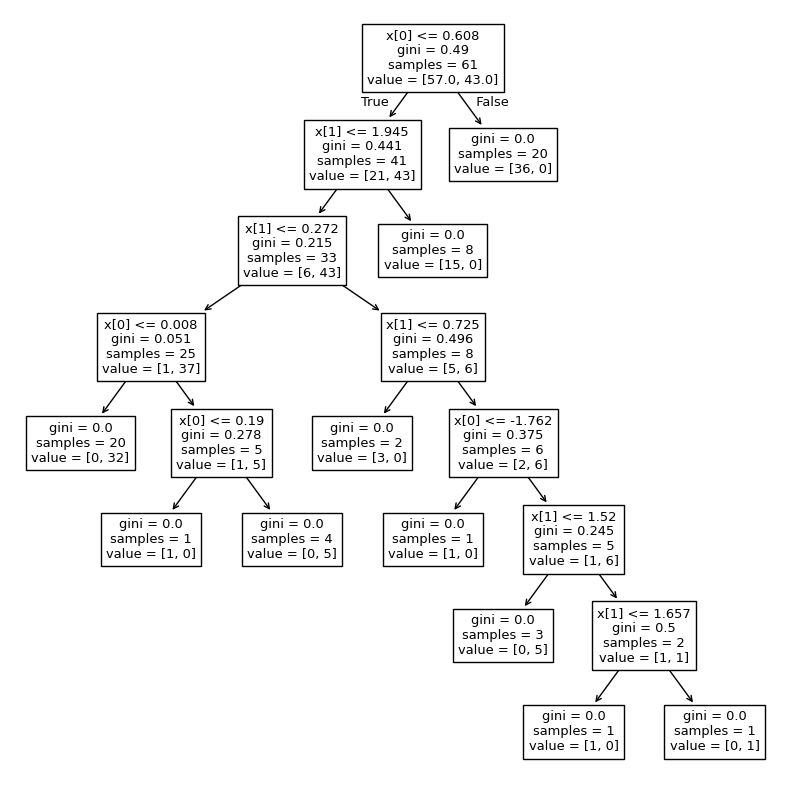

In [6]:
Bagging = bc(max_features =2)
Bagging.fit(df.iloc[:, :-1], df.iloc[:, -1])

print("Visulization of Bagging CLassifiers")
plt.figure(figsize = (10 ,10))
plot_tree(Bagging.estimators_[0])
plt.show()

Visulization of Random Forest


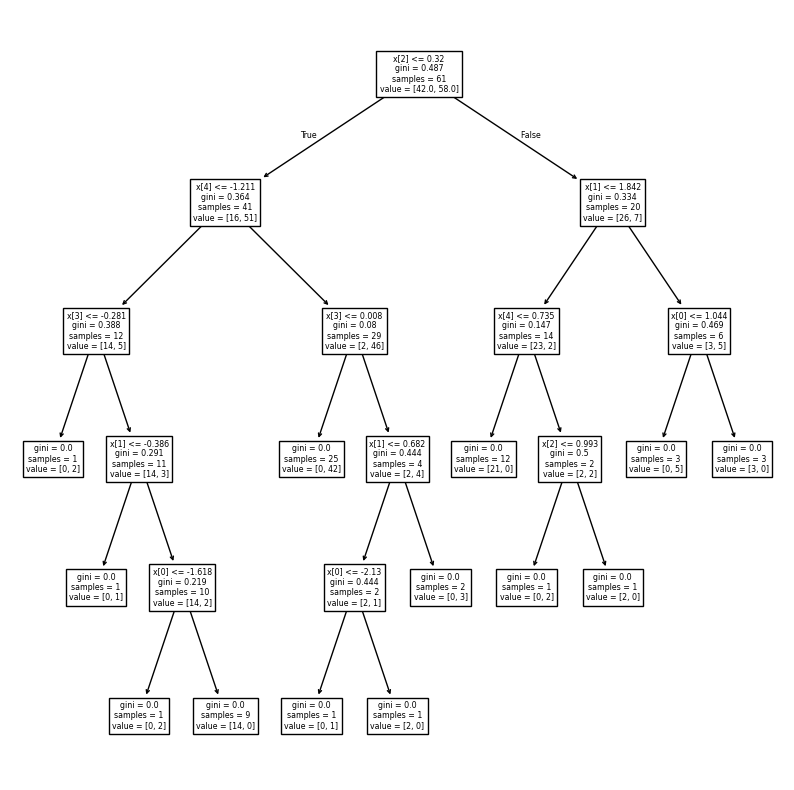

In [7]:
Random_Forest = rfc(max_features =2)
Random_Forest.fit(df.iloc[:, :-1], df.iloc[:, -1])

print("Visulization of Random Forest")
plt.figure(figsize = (10 ,10))
plot_tree(Random_Forest.estimators_[0])
plt.show()

# Classfication Bagging

In [8]:
# data Making and Preprocessing
x, y = mc(
    n_samples=10000,
    n_features=3,
    n_informative=3,
    n_redundant=0,
    n_repeated=0,
    random_state=42
)

# Data Split in Training And Testing
x_train, x_test, y_train, y_test = tts(x, y, test_size = 0.2, stratify = y, shuffle = True)

# Feature Scaling
scaler = ss()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)

In [9]:
# Decision Tree Model

model_dt = dtc() 
# Model Learn Patter by Training Data
model_dt.fit(x_train_sc, y_train)

# Predicting The Value 
y_pred_dt = model_dt.predict(x_test_sc)

# Result of Prediction
Result_Score_dt = cr(y_test, y_pred_dt)
print("Decision Tree : \n", Result_Score_dt)

Decision Tree : 
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      1000
           1       0.93      0.93      0.93      1000

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



In [10]:
# Bagging Model Decision Tree

model_Bagging = bc(
    estimator = dtc(),
    n_estimators = 500,
    bootstrap = True,
    max_samples = 0.5,
    random_state = 42
)
# Model Learn Patter by Training Data
model_Bagging.fit(x_train_sc, y_train)

# Predicting The Value 
y_pred_bag_dt = model_Bagging.predict(x_test_sc)

# Result of Prediction
Result_Score_bag = cr(y_test, y_pred_bag_dt)
print("Decision Tree Bagging Classifier  : \n", Result_Score_bag)



# Bagging Model Support Vector Machine

model_Bagging = bc(
    estimator = SVC(),
    n_estimators = 500,
    bootstrap = True,
    max_samples = 0.5,
    random_state = 42
)
# Model Learn Patter by Training Data
model_Bagging.fit(x_train_sc, y_train)

# Predicting The Value 
y_pred_bag_sv = model_Bagging.predict(x_test_sc)

# Result of Prediction
Result_Score_bag = cr(y_test, y_pred_bag_sv)
print("Support Vector Machine Bagging Classifier  : \n", Result_Score_bag)


Decision Tree Bagging Classifier  : 
               precision    recall  f1-score   support

           0       0.95      0.96      0.96      1000
           1       0.96      0.95      0.96      1000

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000

Support Vector Machine Bagging Classifier  : 
               precision    recall  f1-score   support

           0       0.92      0.94      0.93      1000
           1       0.94      0.92      0.93      1000

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



In [11]:
# Random_Forest Model
model_Random_Forest = rfc(n_estimators = 500, random_state = 42)

# Model Learn Patter by Training Data
model_Random_Forest.fit(x_train_sc, y_train)

# Predicting The Value 
y_pred_rtc = model_Random_Forest.predict(x_test_sc)

# Result of Prediction
Result_Score_rfc = cr(y_test, y_pred_rtc)
print("Random_Forest Classifier  : \n", Result_Score_rfc)

Random_Forest Classifier  : 
               precision    recall  f1-score   support

           0       0.95      0.96      0.95      1000
           1       0.96      0.95      0.95      1000

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



In [12]:
# ACCURACY SCORE
print("dtc:\t", AS(y_test, y_pred_dt)*100)
print("dt bc:\t", AS(y_test, y_pred_bag_dt)*100)
print("sv bc:\t", AS(y_test, y_pred_bag_sv)*100)
print("rfc:\t", AS(y_test, y_pred_rtc)*100)

dtc:	 93.10000000000001
dt bc:	 95.6
sv bc:	 93.25
rfc:	 95.45


In [13]:
# Pasting = Bagging(No Boots_trapping)
# Support Vector Machine Pasting Model Initilization

model_Pasting = bc(
    estimator = SVC(),
    n_estimators = 500,
    bootstrap = False,
    max_samples = 0.5,
    random_state = 42
)
# Model Learn Patter by Training Data
model_Pasting.fit(x_train_sc, y_train)

# Predicting The Value 
y_pred_pas_sv = model_Pasting.predict(x_test_sc)

# Result of Prediction
Result_Score_pas_svm = cr(y_test, y_pred_pas_sv)
print("Support Vector Machine Pasting Classifier  : \n", Result_Score_pas_svm)



# Dicision Tree Pasting Model Initilization
model_Pasting = bc(
    estimator = dtc(),
    n_estimators = 500,
    bootstrap = False,
    max_samples = 0.5,
    random_state = 42
)

# Model Learn Patter by Training Data
model_Pasting.fit(x_train_sc, y_train)

# Predicting The Value 
y_pred_pas_dt = model_Pasting.predict(x_test_sc)

# Result of Prediction
Result_Score_pas_dt = cr(y_test, y_pred_pas_dt)
print("Support Vector Machine Pasting Classifier  : \n", Result_Score_pas_dt)

print("dt", AS(y_test, y_pred_pas_dt))
print("SVM", AS(y_test, y_pred_pas_sv))


# #  Accuracy Score
#  1. Random Forest : 95.7
# 2. Decision Tree Pasting : 95.6
#  3. Decision Tree Bagging : 95.55  
#  4. Decision Tree : 93.5
#  5. SVM Pasting : 93.33
#  6. SVM Bagging : 93.3


Support Vector Machine Pasting Classifier  : 
               precision    recall  f1-score   support

           0       0.92      0.95      0.93      1000
           1       0.94      0.92      0.93      1000

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000

Support Vector Machine Pasting Classifier  : 
               precision    recall  f1-score   support

           0       0.96      0.96      0.96      1000
           1       0.96      0.96      0.96      1000

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000

dt 0.958
SVM 0.9335


In [21]:
# best_F1 = 0
# best_AS = 0
# best_RS = 0
# best_PS = 0

def all_classification(x, y):
    # global best_F1, best_AS, best_RS, best_PS   # ✅ needed to update global variables If Values Assign Outside of Functions

    best_score = {'best_F1': 0, 'best_AS': 0, 'best_RS': 0, 'best_PS': 0}
    best_model = {'F1': '', 'AS': '', 'RS': '', 'PS': ''}

    x_train, x_test, y_train, y_test = tts(
        x, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    models = {
        'Logistic Regression': lc(),
        'K Neighbours Classifier': knc(),
        'Decision Tree Classifier': dtc(random_state=42),
        'Support Vector Classifier': SVC(),
        'Random Forest Classifier': rfc(n_estimators=500, random_state=42, max_samples=0.5),
        'Bagging Classifier': bc(estimator=dtc(), n_estimators=500, random_state=42, max_samples=0.5),
        'Pasting Classifier': bc(estimator=dtc(), n_estimators=500, random_state=42, max_samples=0.5, bootstrap=False)
    }

    models_need_scaling = [
        'Logistic Regression',
        'K Neighbours Classifier',
        'Support Vector Classifier'
    ]

    for name, model in models.items():

        if name in models_need_scaling:
            pipe = Pipeline([
                ('scaler', ss()),
                ('model', model)
            ])
        else:
            pipe = Pipeline([
                ('model', model)
            ])

        pipe.fit(x_train, y_train)
        y_pred = pipe.predict(x_test)

        acc = AS(y_test, y_pred)
        rec = rs(y_test, y_pred, average='macro')
        prec = ps(y_test, y_pred, average='macro')
        f1_score_val = f1(y_test, y_pred, average='macro')

        print("\n" + "*"*10, name, "*"*10)
        print("Accuracy:", acc)
        print("Recall:", rec)
        print("Precision:", prec)
        print("F1 Score:", f1_score_val)
        print("Confusion Matrix\n", cm(y_test, y_pred))

        # ✅ Best score tracking INSIDE the loop
        if acc > best_score["best_AS"]:
            best_score["best_AS"] = acc
            best_model["AS"] = name

        if rec > best_score["best_RS"]:
            best_score["best_RS"] = rec
            best_model["RS"] = name

        if prec > best_score["best_PS"]:
            best_score["best_PS"] = prec
            best_model["PS"] = name

        if f1_score_val > best_score["best_F1"]:
            best_score["best_F1"] = f1_score_val
            best_model["F1"] = name

    print("\n🔥 BEST MODELS SUMMARY 🔥")
    print(f"Best Accuracy Model: {best_model['AS']} => {best_score['best_AS']}")
    print(f"Best Recall Model: {best_model['RS']} => {best_score['best_RS']}")
    print(f"Best Precision Model: {best_model['PS']} => {best_score['best_PS']}")
    print(f"Best F1 Model: {best_model['F1']} => {best_score['best_F1']}")


all_classification(x, y)


********** Logistic Regression **********
Accuracy: 0.865
Recall: 0.865
Precision: 0.8650058400934415
F1 Score: 0.86499945999784
Confusion Matrix
 [[863 137]
 [133 867]]

********** K Neighbours Classifier **********
Accuracy: 0.955
Recall: 0.955
Precision: 0.955045504550455
F1 Score: 0.9549988749718743
Confusion Matrix
 [[960  40]
 [ 50 950]]

********** Decision Tree Classifier **********
Accuracy: 0.933
Recall: 0.933
Precision: 0.9330277137736815
F1 Score: 0.9329989279828477
Confusion Matrix
 [[929  71]
 [ 63 937]]

********** Support Vector Classifier **********
Accuracy: 0.9365
Recall: 0.9365
Precision: 0.9365982346027857
F1 Score: 0.9364964279240707
Confusion Matrix
 [[944  56]
 [ 71 929]]

********** Random Forest Classifier **********
Accuracy: 0.9475
Recall: 0.9475
Precision: 0.9475040275362479
F1 Score: 0.9474998818747342
Confusion Matrix
 [[949  51]
 [ 54 946]]

********** Bagging Classifier **********
Accuracy: 0.9505
Recall: 0.9504999999999999
Precision: 0.950522075581703

# Regression Bagging

In [22]:
# data Making and Preprocessing                                                  
x, y = mr(
    n_samples=10000,
    n_features=3,
    n_informative=3,
    noise=0,
    random_state=42
)

# Data Split in Training And Testing
x_train, x_test, y_train, y_test = tts(x, y, test_size = 0.2, random_state = 42, shuffle = True)

# Feature Scaling
scaler = ss()
x_train_sc = scaler.fit_transform(x_train)
x_test_sc = scaler.transform(x_test)

In [23]:
# Decision Tree Regressor
dtr_model = dtr()
dtr_model.fit(x_train_sc, y_train)

# Prediction by X Test Data
y_pred_dt = dtr_model.predict(x_test)

# Results of R1 Score, Mean Absolute Error, Mean Squared Error, Mean Root Square Error
print(" ** Decision Tree Regressor ** ")
print("R2 : \t\t\t", r2(y_test, y_pred_dt))
print("Mean Absolute Error  : \t", mae(y_test, y_pred_dt))
print("Mean Squared Error : \t", mse(y_test, y_pred_dt))
print("Root Mean Squared Error :", np.sqrt(mse(y_test, y_pred_dt)))

 ** Decision Tree Regressor ** 
R2 : 			 0.9816706396090825
Mean Absolute Error  : 	 12.215926691773404
Mean Squared Error : 	 297.0777826352118
Root Mean Squared Error : 17.235944495014245


In [24]:
# SVR Regressor
SVR_model = SVR()
SVR_model.fit(x_train_sc, y_train)

# Prediction by X Test Data
y_pred_svr = SVR_model.predict(x_test)

# Results of R1 Score, Mean Absolute Error, Mean Squared Error, Mean Root Square Error
print(" ** Support Vector Regressor ** ")
print("R2 : \t\t\t", r2(y_test, y_pred_svr))
print("Mean Absolute Error  : \t", mae(y_test, y_pred_svr))
print("Mean Squared Error : \t", mse(y_test, y_pred_svr))
print("Root Mean Squared Error :", np.sqrt(mse(y_test, y_pred_svr)))

 ** Support Vector Regressor ** 
R2 : 			 0.9355620021554636
Mean Absolute Error  : 	 11.241151217498034
Mean Squared Error : 	 1044.3952821503344
Root Mean Squared Error : 32.31710510163827


In [25]:
# Random Forest Regressor
rfr_model = rfr(n_estimators = 500,
               random_state = 42,
               bootstrap = True,
               )
rfr_model.fit(x_train_sc, y_train)

# Prediction by X Test Data
y_pred_svr = rfr_model.predict(x_test)

# Results of R1 Score, Mean Absolute Error, Mean Squared Error, Mean Root Square Error
print(" ** Support Vector Regressor ** ")
print("R2 : \t\t\t", r2(y_test, y_pred_svr))
print("Mean Absolute Error  : \t", mae(y_test, y_pred_svr))
print("Mean Squared Error : \t", mse(y_test, y_pred_svr))
print("Root Mean Squared Error :", np.sqrt(mse(y_test, y_pred_svr)))

 ** Support Vector Regressor ** 
R2 : 			 0.9946569997547026
Mean Absolute Error  : 	 4.63617313223555
Mean Squared Error : 	 86.59803897351952
Root Mean Squared Error : 9.30580673415903


In [26]:
# Bagging Regressor Decision Tree
bag_model_dt = br(estimator = SVR(),
                    n_estimators = 500,
                    random_state = 42,
                    bootstrap = True,
                    max_samples = 0.25)

bag_model_dt.fit(x_train_sc, y_train)

# Prediction by X Test Data
y_pred_bag_dt = bag_model_dt.predict(x_test)

# Results of R1 Score, Mean Absolute Error, Mean Squared Error, Mean Root Square Error
print(" **  Bagging Regressor ** ")
print("R2 : \t\t\t", r2(y_test, y_pred_bag_dt))
print("Mean Absolute Error  : \t", mae(y_test, y_pred_bag_dt))
print("Mean Squared Error : \t", mse(y_test, y_pred_bag_dt))
print("Root Mean Squared Error :", np.sqrt(mse(y_test, y_pred_bag_dt)))


# Bagging Regressor SVR
bag_model_svr = br(estimator = SVR(),
                    n_estimators = 500,
                    random_state = 42,
                    bootstrap = True,
                    max_samples = 0.25)

bag_model_svr.fit(x_train_sc, y_train)

# Prediction by X Test Data
y_pred_bag_svr = bag_model_svr.predict(x_test)

# Results of R1 Score, Mean Absolute Error, Mean Squared Error, Mean Root Square Error
print(" **  Bagging Regressor ** ")
print("R2 : \t\t\t", r2(y_test, y_pred_bag_svr))
print("Mean Absolute Error  : \t", mae(y_test, y_pred_bag_svr))
print("Mean Squared Error : \t", mse(y_test, y_pred_bag_svr))
print("Root Mean Squared Error :", np.sqrt(mse(y_test, y_pred_bag_svr)))

 **  Bagging Regressor ** 
R2 : 			 0.795747120708368
Mean Absolute Error  : 	 30.19413998130441
Mean Squared Error : 	 3310.4806268571742
Root Mean Squared Error : 57.53677629879149
 **  Bagging Regressor ** 
R2 : 			 0.795747120708368
Mean Absolute Error  : 	 30.19413998130441
Mean Squared Error : 	 3310.4806268571742
Root Mean Squared Error : 57.53677629879149


In [27]:
# Pasting Regressor Decision Tree
paste_model_dt = br(estimator = SVR(),
                    n_estimators = 500,
                    random_state = 42,
                    bootstrap = False,
                    max_samples = 0.25)

paste_model_dt.fit(x_train_sc, y_train)

# Prediction by X Test Data
y_pred_pas_dt = paste_model_dt.predict(x_test)

# Results of R1 Score, Mean Absolute Error, Mean Squared Error, Mean Root Square Error
print(" **  Pasting Regressor ** ")
print("R2 : \t\t\t", r2(y_test, y_pred_pas_dt))
print("Mean Absolute Error  : \t", mae(y_test, y_pred_pas_dt))
print("Mean Squared Error : \t", mse(y_test, y_pred_pas_dt))
print("Root Mean Squared Error :", np.sqrt(mse(y_test, y_pred_pas_dt)))


# Pasting Regressor SVR
paste_model_svr = br(estimator = SVR(),
                    n_estimators = 500,
                    random_state = 42,
                    bootstrap = False,
                    max_samples = 0.25)

paste_model_svr.fit(x_train_sc, y_train)

# Prediction by X Test Data
y_pred_paste_svr = paste_model_svr.predict(x_test)

# Results of R1 Score, Mean Absolute Error, Mean Squared Error, Mean Root Square Error
print(" **  Pasting Regressor ** ")
print("R2 : \t\t\t", r2(y_test, y_pred_paste_svr))
print("Mean Absolute Error  : \t", mae(y_test, y_pred_paste_svr))
print("Mean Squared Error : \t", mse(y_test, y_pred_paste_svr))
print("Root Mean Squared Error :", np.sqrt(mse(y_test, y_pred_paste_svr)))

 **  Pasting Regressor ** 
R2 : 			 0.7958810023497902
Mean Absolute Error  : 	 30.18802123761078
Mean Squared Error : 	 3308.3107060131824
Root Mean Squared Error : 57.517916391444345
 **  Pasting Regressor ** 
R2 : 			 0.7958810023497902
Mean Absolute Error  : 	 30.18802123761078
Mean Squared Error : 	 3308.3107060131824
Root Mean Squared Error : 57.517916391444345


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def all_regressors(x, y):

    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "KNN": KNeighborsRegressor(),
        "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
        "Bagging Decision Tree": BaggingRegressor(
            estimator=DecisionTreeRegressor(),
            n_estimators=100,
            random_state=42
        ),
        "Bagging SVR": BaggingRegressor(
            estimator=SVR(),
            n_estimators=50,
            random_state=42
        ),
        "Bagging KNN": BaggingRegressor(
            estimator=KNeighborsRegressor(),
            n_estimators=50,
            random_state=42
        )
    }

    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42
    )

    for name, model in models.items():
        print("="*10, name, "="*10)

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        pipe.fit(x_train, y_train)
        y_pred = pipe.predict(x_test)

        print("R2 Score:", r2_score(y_test, y_pred))
        print("MAE:", mean_absolute_error(y_test, y_pred))
        print("MSE:", mean_squared_error(y_test, y_pred))
        print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
        print()


all_regressors(x, y)

========== Linear Regression ==========
R2 Score: 1.0
MAE: 5.491565535642451e-14
MSE: 4.9067722093203404e-27
RMSE: 7.004835622140137e-14

========== Decision Tree ==========
R2 Score: 0.9805001928447132
MAE: 12.389693549588984
MSE: 316.04809703983705
RMSE: 17.777741618097533

========== KNN ==========
R2 Score: 0.994781918756333
MAE: 5.563220293508962
MSE: 84.57338239948061
RMSE: 9.196378765551177

========== Random Forest ==========
R2 Score: 0.9946842825458022
MAE: 4.680184228345477
MSE: 86.15584617949331
RMSE: 9.282017355052366

========== Bagging Decision Tree ==========
R2 Score: 0.9946873666282413
MAE: 4.782565435489752
MSE: 86.1058601269011
RMSE: 9.279324335688516

========== Bagging SVR ==========
R2 Score: 0.934893647162645
MAE: 11.277690508956951
MSE: 1055.2278161310676
RMSE: 32.48427028780341

========== Bagging KNN ==========
R2 Score: 0.9954802941837394
MAE: 4.991156086679197
MSE: 73.25428456977218
RMSE: 8.558871687890418



In [ ]:
def all_regressor(x, y):
    
    x_train, x_test, y_train, y_test = tts(x, y, test_size = 0.2, random_state = 42)
    
    models = {
        'Linear Regression' : lr(),
        'K Neighbours Regressor' : knr(n_neighbors = 10),
        'Decision Tree Regressor' : dtr(random_state = 42),
        'Support Vector Regressor' : SVR(),
        'Random Forest Regressor' : rfr(n_estimators = 500, random_state = 42, max_samples = 0.5),
        'Bagging Regressor' : br(estimator = dtr(), n_estimators = 500, random_state = 42, max_samples = 0.5),
        'Pasting Regressor' : br(estimator = dtr(), n_estimators = 500, random_state = 42, bootstrap = False)
    }
    
    models_need_scaling = ['Linear Regression', 'K Neighbours Regressor', 'Support Vector Regressor']

    # ✅ Move outside loop
    best_score = {
        'Mean Absolute Error': float('inf'),
        'Mean Squared Error': float('inf'),
        'Root Mean Squared Error': float('inf'),
        'R2 Score': -float('inf'),
        'Adjusted R2': -float('inf')
    }

    best_model = {'MAE': '', 'MSE': '', 'RMSE': '', 'R2': '', 'ADJ_R2': ''}

    for name, model in models.items():

        if name in models_need_scaling:
            pipe = Pipeline([
                ('scaler', ss()),
                ('model', model) ])
        else:
            pipe = Pipeline([
                ('model', model) ])

        pipe.fit(x_train, y_train)

        y_pred = pipe.predict(x_test)

        # Matrics
        Mae = mae(y_test, y_pred)
        Mse = mse(y_test, y_pred)
        Rmse = rmse(y_test, y_pred)
        R2 = r2(y_test, y_pred)
        
        n = x_test.shape[0]
        k = x_test.shape[1]
        Adjusted_R2 = 1 - ((1 - R2) * (n-1)) / (n-1-k)

        print()
        print("*"* 10, name, "*"*10)
        print("Mean Absolute Error :\t", Mae)
        print("Mean Squared Error :\t", Mse)
        print("Root Mean Squared Error :\t", Rmse)
        print("R2 Error :\t", R2)
        print("Adjusted R2 Error :\t", Adjusted_R2)
        print()

        # Best Results
        if Mae < best_score["Mean Absolute Error"]:
            best_score["Mean Absolute Error"] = Mae
            best_model['MAE'] = name

        if Mse < best_score["Mean Squared Error"]:
            best_score["Mean Squared Error"] = Mse
            best_model['MSE'] = name

        if Rmse < best_score["Root Mean Squared Error"]:
            best_score["Root Mean Squared Error"] = Rmse
            best_model['RMSE'] = name

        if R2 > best_score["R2 Score"]:
            best_score["R2 Score"] = R2
            best_model["R2"] = name

        if Adjusted_R2 > best_score["Adjusted R2"]:
            best_score["Adjusted R2"] = Adjusted_R2
            best_model["ADJ_R2"] = name

    print()
    print(best_score)
    print(best_model)
    print()

all_regressor(x, y)

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def regression_benchmark(X, y, cv=5, test_size=0.2, random_state=42):

    # ============================
    # 1️⃣ Train-Test Split
    # ============================
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # ============================
    # 2️⃣ Models Dictionary
    # ============================
    models = {
        "Linear Regression": LinearRegression(),
        "KNN Regressor": KNeighborsRegressor(n_neighbors=10),
        "Decision Tree": DecisionTreeRegressor(random_state=random_state),
        "SVR": SVR(),
        "Random Forest": RandomForestRegressor(
            n_estimators=300, random_state=random_state, max_samples=0.7, n_jobs=-1
        ),
        "Bagging": BaggingRegressor(
            estimator=DecisionTreeRegressor(),
            n_estimators=200,
            random_state=random_state,
            max_samples=0.7
        )
    }

    models_need_scaling = ["Linear Regression", "KNN Regressor", "SVR"]

    results = []

    # ============================
    # 3️⃣ Model Training + CV + Evaluation
    # ============================
    for name, model in models.items():

        if name in models_need_scaling:
            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("model", model)
            ])
        else:
            pipe = Pipeline([
                ("model", model)
            ])

        # Cross-validation (R2)
        cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="r2")

        # Train model
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        # Metrics
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)

        # Adjusted R2
        n = X_test.shape[0]
        k = X_test.shape[1]
        adj_r2 = 1 - ((1 - r2) * (n - 1)) / (n - k - 1)

        results.append({
            "Model": name,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2,
            "Adjusted_R2": adj_r2,
            "CV_R2_Mean": cv_scores.mean(),
            "CV_R2_STD": cv_scores.std()
        })

    # ============================
    # 4️⃣ Results DataFrame + Ranking
    # ============================
    results_df = pd.DataFrame(results)

    # Ranking (higher R2 & CV_R2 better, lower RMSE better)
    results_df["Rank"] = (
        results_df["RMSE"].rank(method="min") +
        (-results_df["R2"]).rank(method="min") +
        (-results_df["CV_R2_Mean"]).rank(method="min")
    )

    results_df = results_df.sort_values("Rank")

    return results_df


regression_benchmark(x,y)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression, f_classif, RFE

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import SVR, SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, f1_score


def AutoML(X, y, task="regression", test_size=0.2, cv=5, random_state=42):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # ============================
    # MODELS + HYPERPARAMETERS
    # ============================

    if task == "regression":
        models = {
            "Linear Regression": (LinearRegression(), {}),
            "KNN": (KNeighborsRegressor(), {"model__n_neighbors": [3, 5, 7, 9]}),
            "Decision Tree": (DecisionTreeRegressor(random_state=random_state),
                              {"model__max_depth": [None, 5, 10, 20]}),
            "SVR": (SVR(), {"model__C": [0.1, 1, 10], "model__gamma": ["scale", 0.1, 0.01]}),
            "Random Forest": (RandomForestRegressor(random_state=random_state),
                              {"model__n_estimators": [100, 300],
                               "model__max_depth": [None, 10, 20]})
        }
        scoring = "r2"
        selector = SelectKBest(score_func=f_regression, k="all")

    else:  # classification
        models = {
            "Logistic Regression": (LogisticRegression(max_iter=1000), {}),
            "KNN": (KNeighborsClassifier(), {"model__n_neighbors": [3, 5, 7]}),
            "Decision Tree": (DecisionTreeClassifier(random_state=random_state),
                              {"model__max_depth": [None, 5, 10]}),
            "SVM": (SVC(), {"model__C": [0.1, 1, 10], "model__gamma": ["scale", 0.1]}),
            "Random Forest": (RandomForestClassifier(random_state=random_state),
                              {"model__n_estimators": [100, 300],
                               "model__max_depth": [None, 10, 20]})
        }
        scoring = "f1_weighted"
        selector = SelectKBest(score_func=f_classif, k="all")

    leaderboard = []

    # ============================
    # TRAIN + FEATURE SELECTION + TUNING
    # ============================

    for name, (model, params) in models.items():

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("feature_selection", selector),
            ("model", model)
        ])

        # Hyperparameter tuning
        if params:
            search = RandomizedSearchCV(pipe, params, cv=cv, scoring=scoring, n_iter=10, random_state=random_state)
            search.fit(X_train, y_train)
            best_model = search.best_estimator_
        else:
            best_model = pipe.fit(X_train, y_train)

        y_pred = best_model.predict(X_test)

        # ============================
        # METRICS
        # ============================

        if task == "regression":
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)

            score = r2
            leaderboard.append([name, mae, rmse, r2])

        else:
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average="weighted")

            score = f1
            leaderboard.append([name, acc, f1])

    # ============================
    # LEADERBOARD
    # ============================

    if task == "regression":
        df = pd.DataFrame(leaderboard, columns=["Model", "MAE", "RMSE", "R2"])
        df = df.sort_values("R2", ascending=False)
    else:
        df = pd.DataFrame(leaderboard, columns=["Model", "Accuracy", "F1"])
        df = df.sort_values("F1", ascending=False)

    return df


AutoML(x, y, task="regression")
